# Bouquet `read_geqdsk()` vs OMFIT `OMFITgeqdsk` — Comprehensive Comparison

This notebook performs a quantity-by-quantity comparison of every geqdsk
field between bouquet's native `read_geqdsk()` reader and OMFIT's
`OMFITgeqdsk`.

**Reference data**: `omfit_reference.h5` was generated using
`OMFITgeqdsk` (v3.2026.8.2) with scipy 1.13 / numpy 1.26 (the latest
versions compatible with OMFIT's `interp2d` usage).  The HDF5 file is
self-contained so users without `omfit_classes` can still run this
notebook.

**Test equilibrium**: `d3dlike.geqdsk` — a TokaMaker-generated
DIII-D–like lower-single-null H-mode equilibrium (257×257 grid).

## 1. Setup

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '../..'))
from bouquet import read_geqdsk, GEQDSKEquilibrium

## 2. Load data

In [2]:
# Bouquet native reader
eq = read_geqdsk('d3dlike.geqdsk')

# OMFIT reference from HDF5
ref = h5py.File('omfit_reference.h5', 'r')

psi_N = np.array(ref['psi_N'])
print(f"Bouquet psi_N: {len(eq.psi_N)} points")
print(f"OMFIT  psi_N:  {len(psi_N)} points")

Bouquet psi_N: 257 points
OMFIT  psi_N:  257 points


## 3. Comparison helpers

In [3]:
def compare_scalar(name, bouquet_val, omfit_val):
    """Print a scalar comparison."""
    diff = bouquet_val - omfit_val
    rel = abs(diff / omfit_val) * 100 if omfit_val != 0 else 0
    status = "✓" if rel < 0.01 else "~" if rel < 1.0 else "✗"
    print(f"  {status} {name:20s}  bouquet={bouquet_val:>14.8g}  "
          f"omfit={omfit_val:>14.8g}  Δ={diff:+.3e}  ({rel:.4f}%)")
    return rel

def compare_profile(name, bouquet_arr, omfit_arr, psi_b=None, psi_o=None,
                    skip_zero=True):
    """Print profile comparison metrics and return (max_err, mean_err)."""
    if psi_b is None:
        psi_b = eq.psi_N
    if psi_o is None:
        psi_o = psi_N

    # Interpolate OMFIT onto bouquet grid if grids differ
    if len(psi_b) != len(psi_o) or not np.allclose(psi_b, psi_o):
        from scipy.interpolate import interp1d
        omfit_interp = interp1d(psi_o, omfit_arr, fill_value='extrapolate')(psi_b)
    else:
        omfit_interp = omfit_arr

    diff = bouquet_arr - omfit_interp
    denom = np.maximum(np.abs(omfit_interp), 1e-30)
    if skip_zero:
        mask = np.abs(omfit_interp) > 1e-10 * np.max(np.abs(omfit_interp))
    else:
        mask = np.ones(len(bouquet_arr), dtype=bool)

    if mask.sum() == 0:
        print(f"  {name:25s}: all zeros, skipping")
        return 0, 0

    rel_err = np.abs(diff[mask] / denom[mask]) * 100
    max_err = np.max(rel_err)
    mean_err = np.mean(rel_err)
    status = "✓" if max_err < 0.1 else "~" if max_err < 1.0 else "△" if max_err < 5.0 else "✗"
    print(f"  {status} {name:25s}  max={max_err:8.4f}%  mean={mean_err:8.4f}%  "
          f"(N={mask.sum()}/{len(bouquet_arr)})")
    return max_err, mean_err

def plot_comparison(ax, psi_b, bouquet_arr, psi_o, omfit_arr, ylabel, title):
    """Plot bouquet vs OMFIT on one axis."""
    ax.plot(psi_o, omfit_arr, 'k-', lw=1.5, label='OMFIT', alpha=0.7)
    ax.plot(psi_b, bouquet_arr, 'r--', lw=1.0, label='bouquet')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(ls=':')

## 4. Scalar quantities

In [4]:
print("="*80)
print("SCALAR COMPARISON")
print("="*80)
scalar_map = [
    ("R_mag",    eq.R_mag,       ref['scalars'].attrs['RMAXIS']),
    ("Z_mag",    eq.Z_mag,       ref['scalars'].attrs['ZMAXIS']),
    ("R_center", eq.R_center,    ref['scalars'].attrs['RCENTR']),
    ("B_center", eq.B_center,    ref['scalars'].attrs['BCENTR']),
    ("psi_axis", eq.psi_axis,    ref['scalars'].attrs['SIMAG']),
    ("psi_bdy",  eq.psi_boundary,ref['scalars'].attrs['SIBRY']),
    ("Ip",       eq.Ip,          ref['scalars'].attrs['CURRENT']),
]
for name, bv, ov in scalar_map:
    compare_scalar(name, bv, ov)

SCALAR COMPARISON
  ✓ R_mag                 bouquet=     1.7438176  omfit=     1.7438176  Δ=+0.000e+00  (0.0000%)
  ✓ Z_mag                 bouquet= -0.0053155799  omfit= -0.0053155799  Δ=+0.000e+00  (0.0000%)
  ✓ R_center              bouquet=     1.6795535  omfit=     1.6795535  Δ=+0.000e+00  (0.0000%)
  ✓ B_center              bouquet=     2.0243475  omfit=     2.0243475  Δ=+0.000e+00  (0.0000%)
  ✓ psi_axis              bouquet=    0.34827584  omfit=    0.34827584  Δ=+0.000e+00  (0.0000%)
  ✓ psi_bdy               bouquet=   0.044024881  omfit=   0.044024881  Δ=+0.000e+00  (0.0000%)
  ✓ Ip                    bouquet=     1200039.5  omfit=     1200039.5  Δ=+0.000e+00  (0.0000%)


## 5. Raw g-file profiles (FPOL, PRES, PPRIME, FFPRIM, QPSI, rhovn)

RAW PROFILE COMPARISON (stored directly in g-file)
  ✓ FPOL                       max=  0.0000%  mean=  0.0000%  (N=257/257)
  ✓ PRES                       max=  0.0000%  mean=  0.0000%  (N=256/257)
  ✓ PPRIME                     max=  0.0000%  mean=  0.0000%  (N=256/257)
  ✓ FFPRIM                     max=  0.0000%  mean=  0.0000%  (N=256/257)
  ✓ QPSI                       max=  0.0000%  mean=  0.0000%  (N=257/257)
  ✓ rhovn                      max=  0.0000%  mean=  0.0000%  (N=256/257)


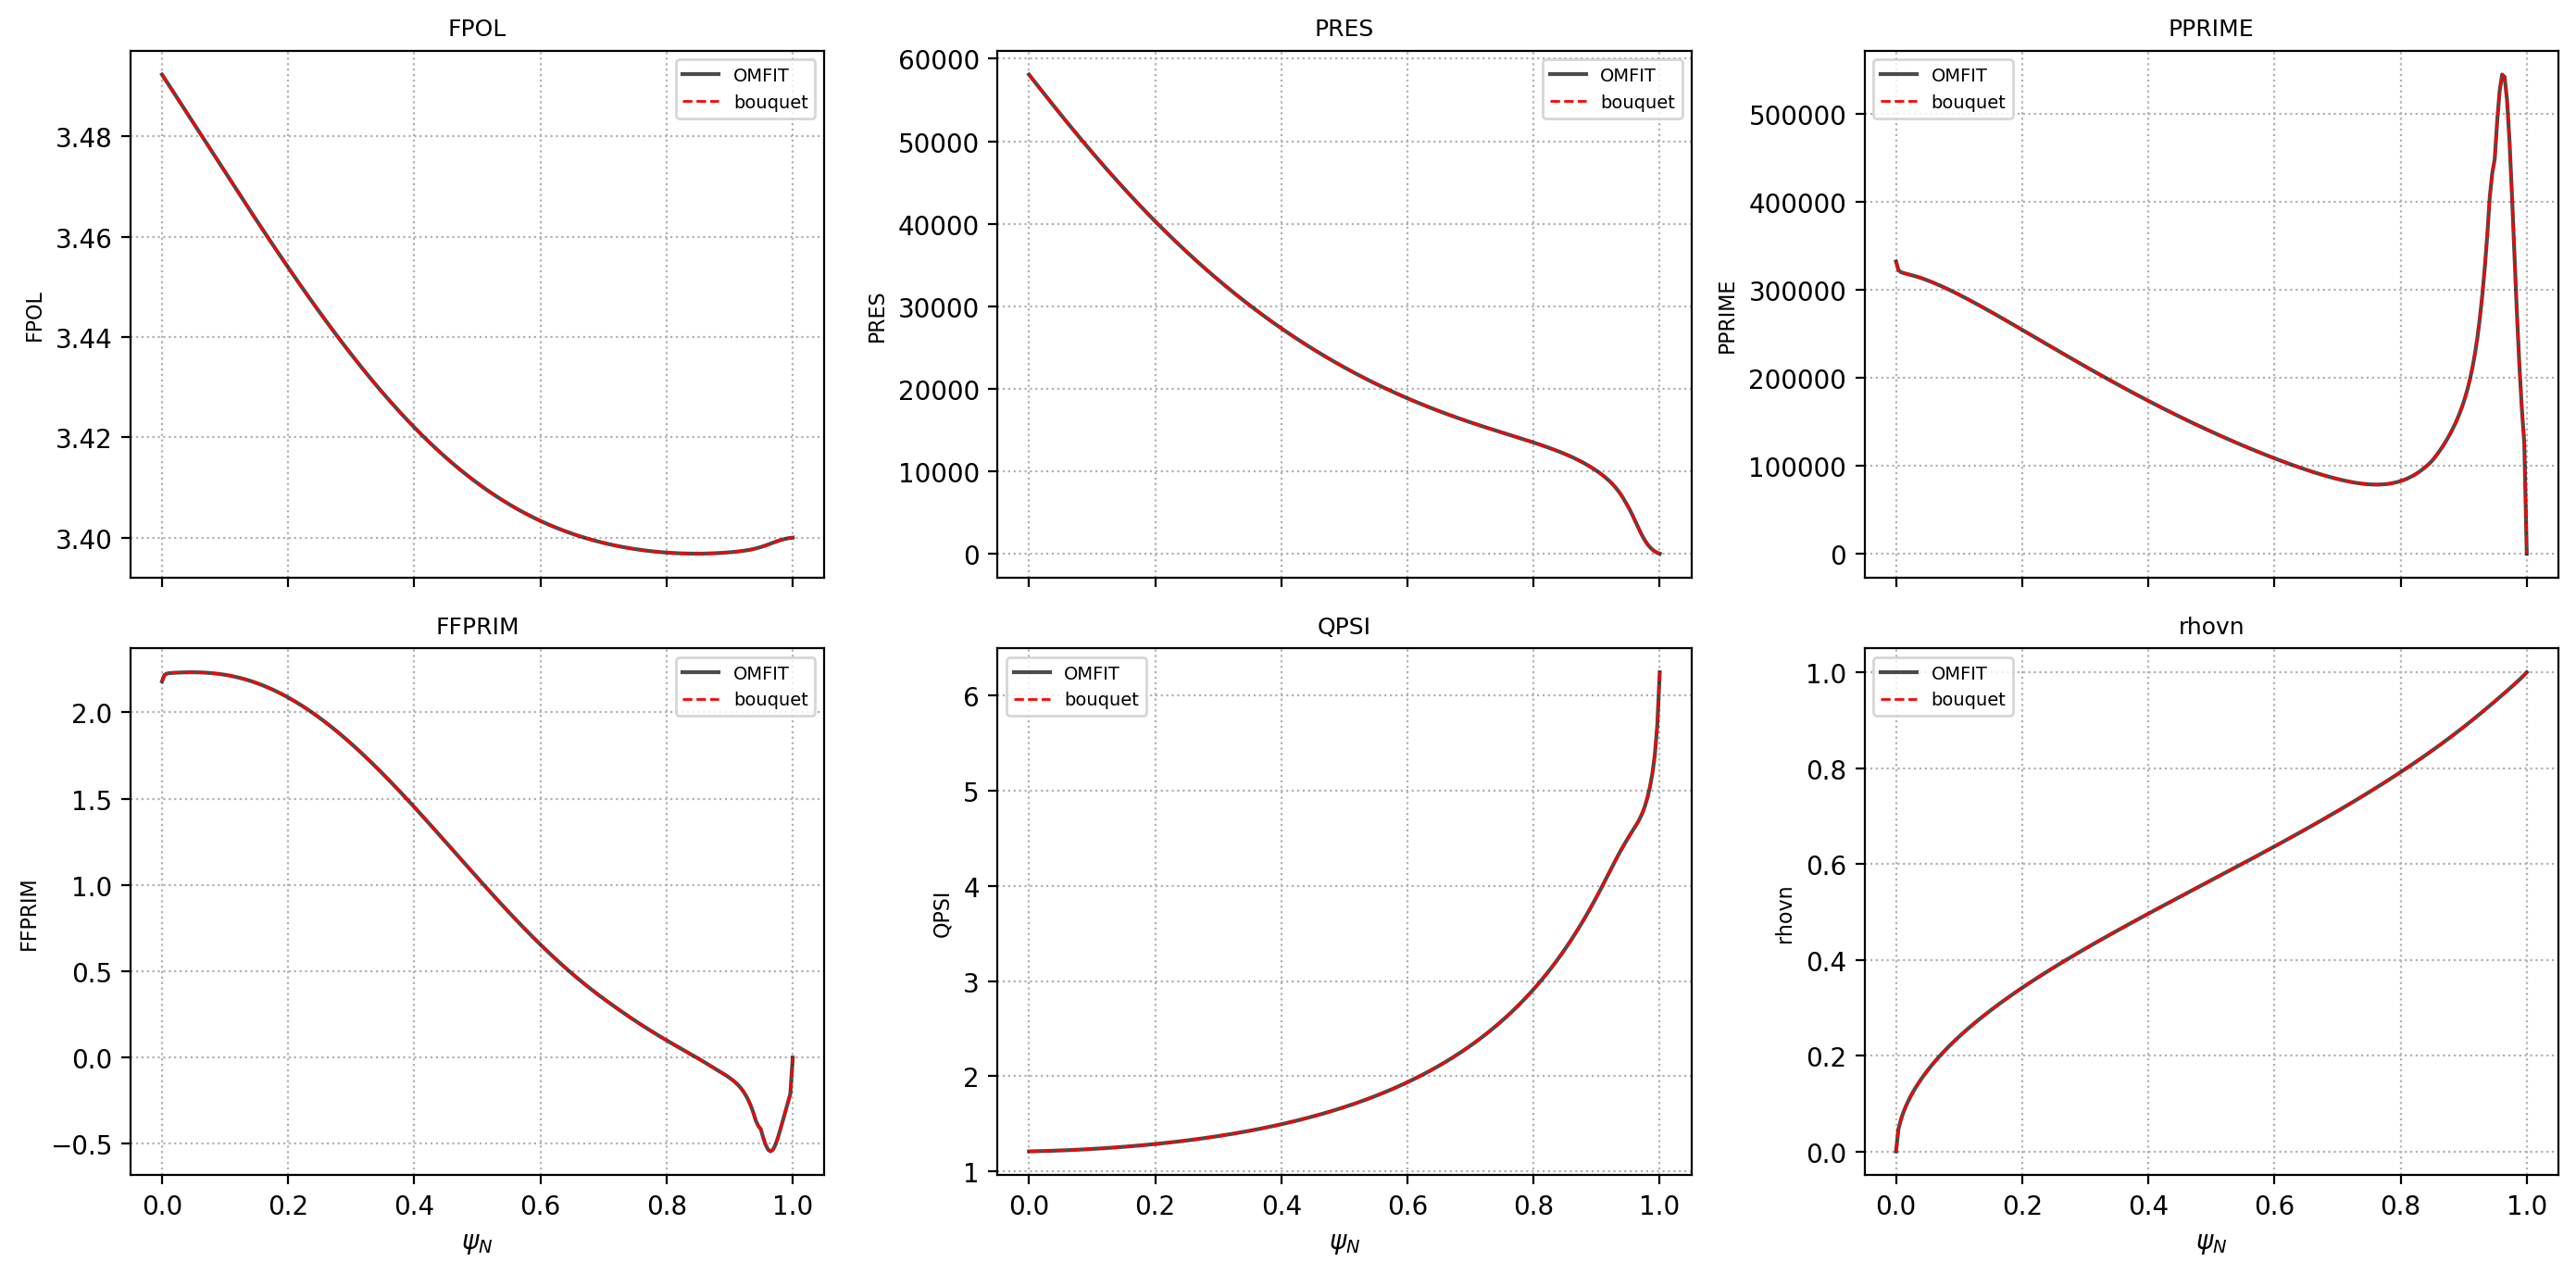

In [5]:
print("="*80)
print("RAW PROFILE COMPARISON (stored directly in g-file)")
print("="*80)

psi_b = np.linspace(0, 1, len(eq.fpol))

raw_profiles = [
    ("FPOL",    eq.fpol,   np.array(ref['profiles/FPOL'])),
    ("PRES",    eq.pres,   np.array(ref['profiles/PRES'])),
    ("PPRIME",  eq.pprime, np.array(ref['profiles/PPRIME'])),
    ("FFPRIM",  eq.ffprim, np.array(ref['profiles/FFPRIM'])),
    ("QPSI",    eq.qpsi,   np.array(ref['profiles/QPSI'])),
    ("rhovn",   eq.rhovn,  np.array(ref['profiles/rhovn'])),
]

for name, barr, oarr in raw_profiles:
    compare_profile(name, barr, oarr, psi_b=psi_b, psi_o=psi_N)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for idx, (name, barr, oarr) in enumerate(raw_profiles):
    r, c = divmod(idx, 3)
    plot_comparison(axes[r][c], psi_b, barr, psi_N, oarr, name, name)
axes[1][0].set_xlabel(r'$\psi_N$')
axes[1][1].set_xlabel(r'$\psi_N$')
axes[1][2].set_xlabel(r'$\psi_N$')
plt.tight_layout()
plt.show()

## 6. 2-D grid (PSIRZ)

2-D GRID COMPARISON
  bouquet PSIRZ shape: (257, 257)
  OMFIT   PSIRZ shape: (257, 257)
  max |Δ|: 0.000e+00
  mean|Δ|: 0.000e+00


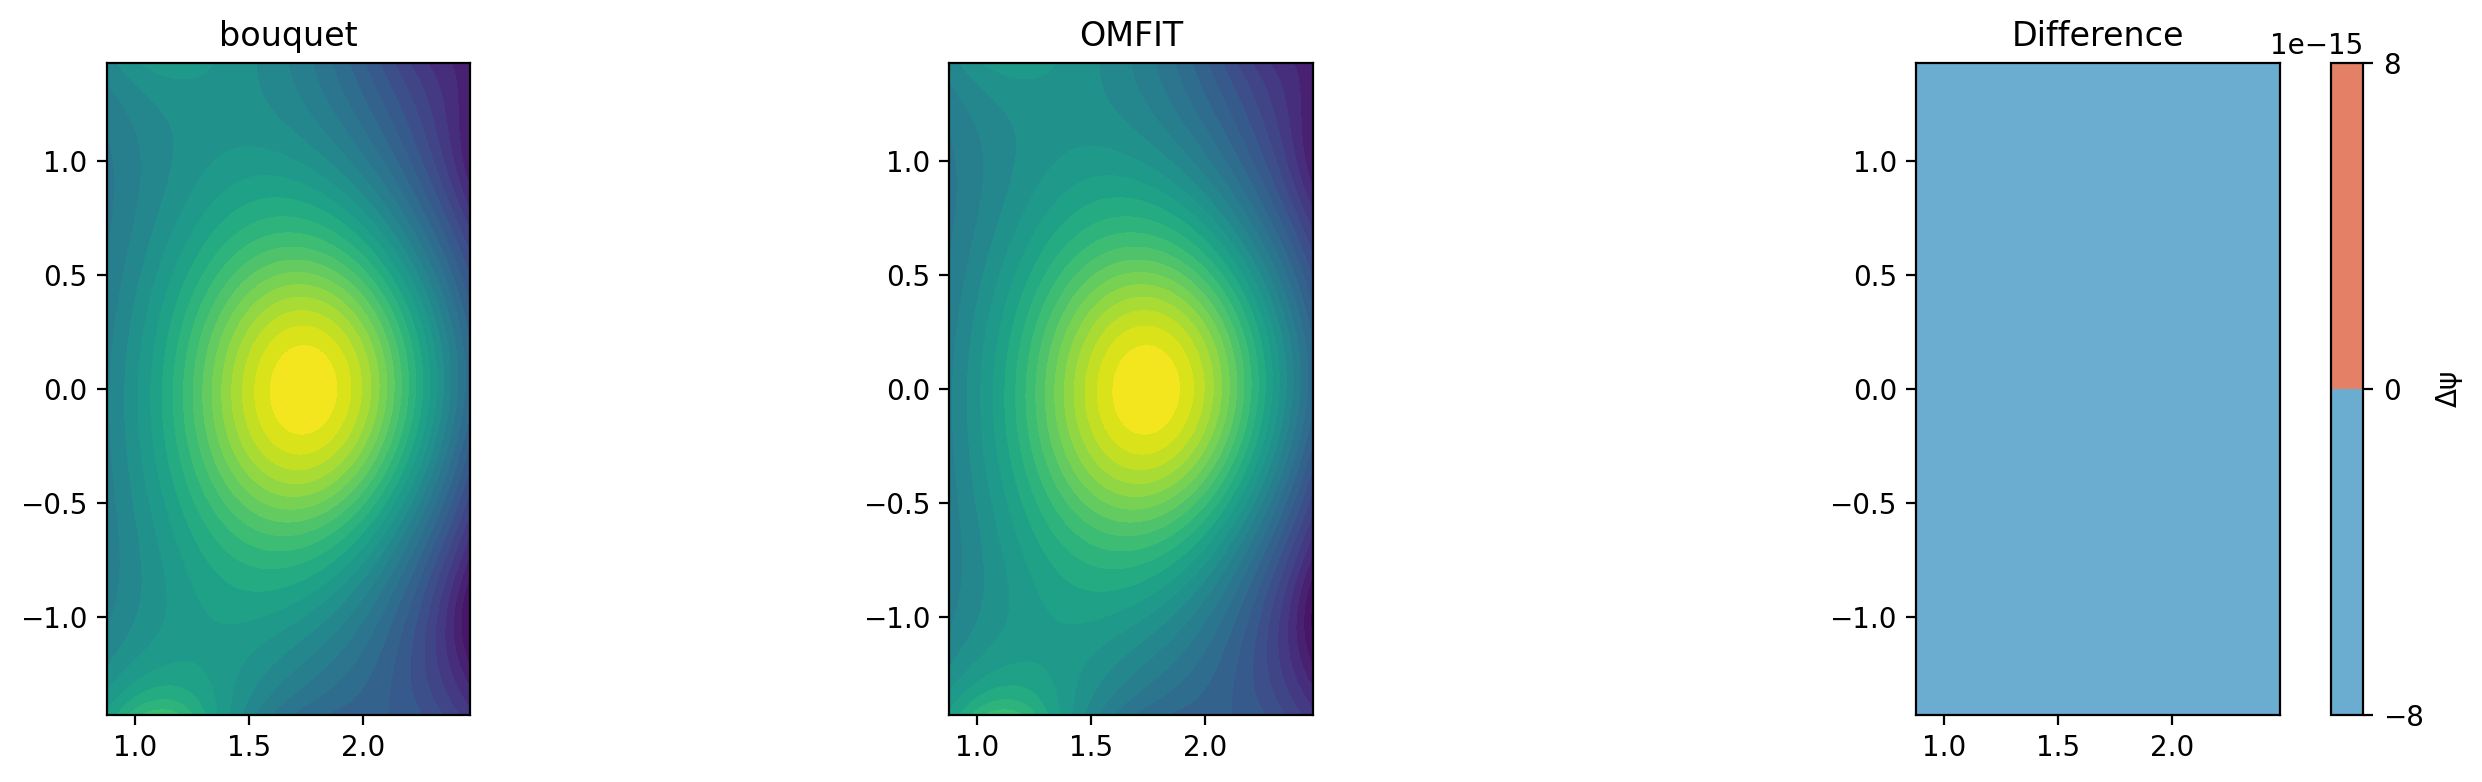

In [6]:
print("="*80)
print("2-D GRID COMPARISON")
print("="*80)

psirz_omfit = np.array(ref['grid/PSIRZ'])
psirz_bouquet = eq.psi_RZ

print(f"  bouquet PSIRZ shape: {psirz_bouquet.shape}")
print(f"  OMFIT   PSIRZ shape: {psirz_omfit.shape}")

diff = psirz_bouquet - psirz_omfit
print(f"  max |Δ|: {np.max(np.abs(diff)):.3e}")
print(f"  mean|Δ|: {np.mean(np.abs(diff)):.3e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].set_title('bouquet')
axes[0].contourf(eq.R_grid, eq.Z_grid, psirz_bouquet, levels=30)
axes[0].set_aspect('equal')
axes[1].set_title('OMFIT')
R_o = np.array(ref['grid/R'])
Z_o = np.array(ref['grid/Z'])
axes[1].contourf(R_o, Z_o, psirz_omfit, levels=30)
axes[1].set_aspect('equal')
axes[2].set_title('Difference')
im = axes[2].contourf(eq.R_grid, eq.Z_grid, diff, levels=30, cmap='RdBu_r')
axes[2].set_aspect('equal')
plt.colorbar(im, ax=axes[2], label='Δψ')
plt.tight_layout()
plt.show()

## 7. Boundary (RBBBS, ZBBBS)

BOUNDARY COMPARISON
  bouquet boundary: 257 points
  OMFIT   boundary: 257 points
  ✓ boundary R                 max=  0.0000%  mean=  0.0000%  (N=257/257)
  ✓ boundary Z                 max=  0.0000%  mean=  0.0000%  (N=257/257)


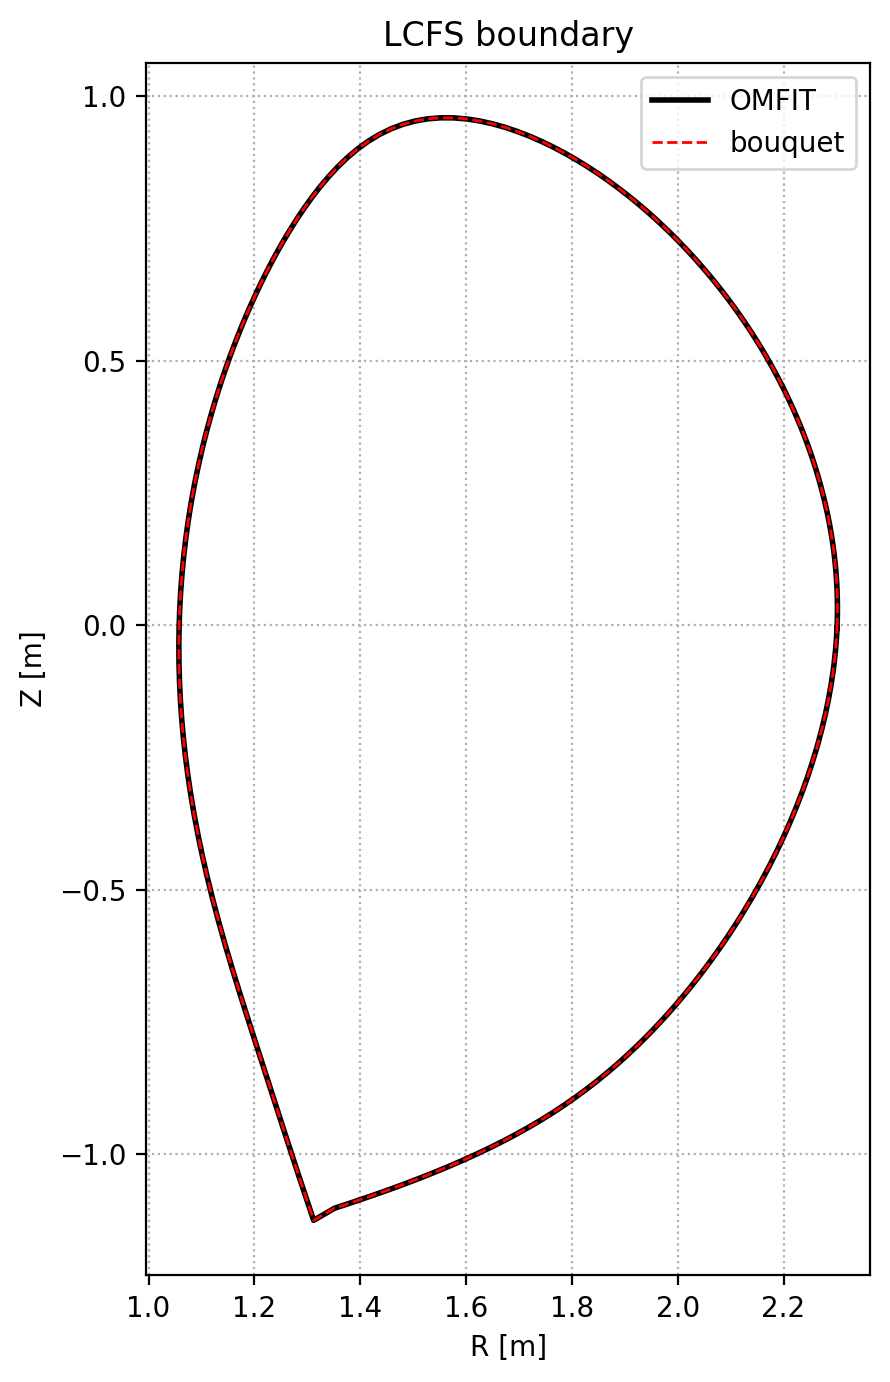

In [7]:
print("="*80)
print("BOUNDARY COMPARISON")
print("="*80)

bR_o = np.array(ref['boundary/RBBBS'])
bZ_o = np.array(ref['boundary/ZBBBS'])
print(f"  bouquet boundary: {len(eq.boundary_R)} points")
print(f"  OMFIT   boundary: {len(bR_o)} points")

compare_profile("boundary R", eq.boundary_R, bR_o, skip_zero=False)
compare_profile("boundary Z", eq.boundary_Z, bZ_o, skip_zero=False)

fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(bR_o, bZ_o, 'k-', lw=2, label='OMFIT')
ax.plot(eq.boundary_R, eq.boundary_Z, 'r--', lw=1, label='bouquet')
ax.set_aspect('equal')
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title('LCFS boundary')
ax.legend()
ax.grid(ls=':')
plt.tight_layout()
plt.show()

## 8. Flux-surface averaged quantities

These are the core numerical output — where differences matter most.
Bouquet computes these independently from OMFIT using its own contour
tracing, resampling, and flux-expansion weighting.

In [8]:
print("="*80)
print("FLUX-SURFACE AVERAGE COMPARISON")
print("="*80)

avg_map = {
    'R':          ('averages/R',          eq.averages['R']),
    '1/R':        ('averages/1_over_R',   eq.averages['1/R']),
    '1/R^2':      ('averages/1_over_Rsq2',eq.averages['1/R**2']),
    'R^2':        ('averages/Rsq2',       eq.averages['R**2']),
    '<Bp>':       ('averages/Bp',         eq.averages['Bp']),
    '<Bp^2>':     ('averages/Bpsq2',      eq.averages['Bp**2']),
    '<Bt>':       ('averages/Bt',         eq.averages['Bt']),
    '<Bt^2>':     ('averages/Btsq2',      eq.averages['Bt**2']),
    '<Btot^2>':   ('averages/Btotsq2',    eq.averages['Btot**2']),
    'F':          ('averages/F',          eq.averages['F']),
    'PPRIME':     ('averages/PPRIME',     eq.averages['PPRIME']),
    'FFPRIM':     ('averages/FFPRIM',     eq.averages['FFPRIM']),
    'vp':         ('averages/vp',         eq.averages['vp']),
    'q':          ('averages/q',          eq.averages['q']),
    'ip':         ('averages/ip',         eq.averages['ip']),
}

results = {}
for name, (h5_path, bouquet_arr) in avg_map.items():
    omfit_arr = np.array(ref[h5_path])
    mx, mn = compare_profile(name, bouquet_arr, omfit_arr)
    results[name] = (mx, mn)

FLUX-SURFACE AVERAGE COMPARISON
  △ R                          max=  1.2272%  mean=  0.0059%  (N=257/257)
  ~ 1/R                        max=  0.8953%  mean=  0.0046%  (N=257/257)
  △ 1/R^2                      max=  1.4363%  mean=  0.0079%  (N=257/257)
  △ R^2                        max=  2.6930%  mean=  0.0128%  (N=257/257)
  ✗ <Bp>                       max=100.0000%  mean=  0.4313%  (N=257/257)
  ✗ <Bp^2>                     max=100.0000%  mean=  0.4447%  (N=257/257)
  ~ <Bt>                       max=  0.8953%  mean=  0.0046%  (N=257/257)
  △ <Bt^2>                     max=  1.4363%  mean=  0.0079%  (N=257/257)
  △ <Btot^2>                   max=  1.3469%  mean=  0.0074%  (N=257/257)
  ✓ F                          max=  0.0000%  mean=  0.0000%  (N=257/257)
  ✓ PPRIME                     max=  0.0000%  mean=  0.0000%  (N=256/257)
  ✓ FFPRIM                     max=  0.0000%  mean=  0.0000%  (N=256/257)
  ✗ vp                         max=100.0000%  mean=  0.4351%  (N=257/257)
  ✗ q 

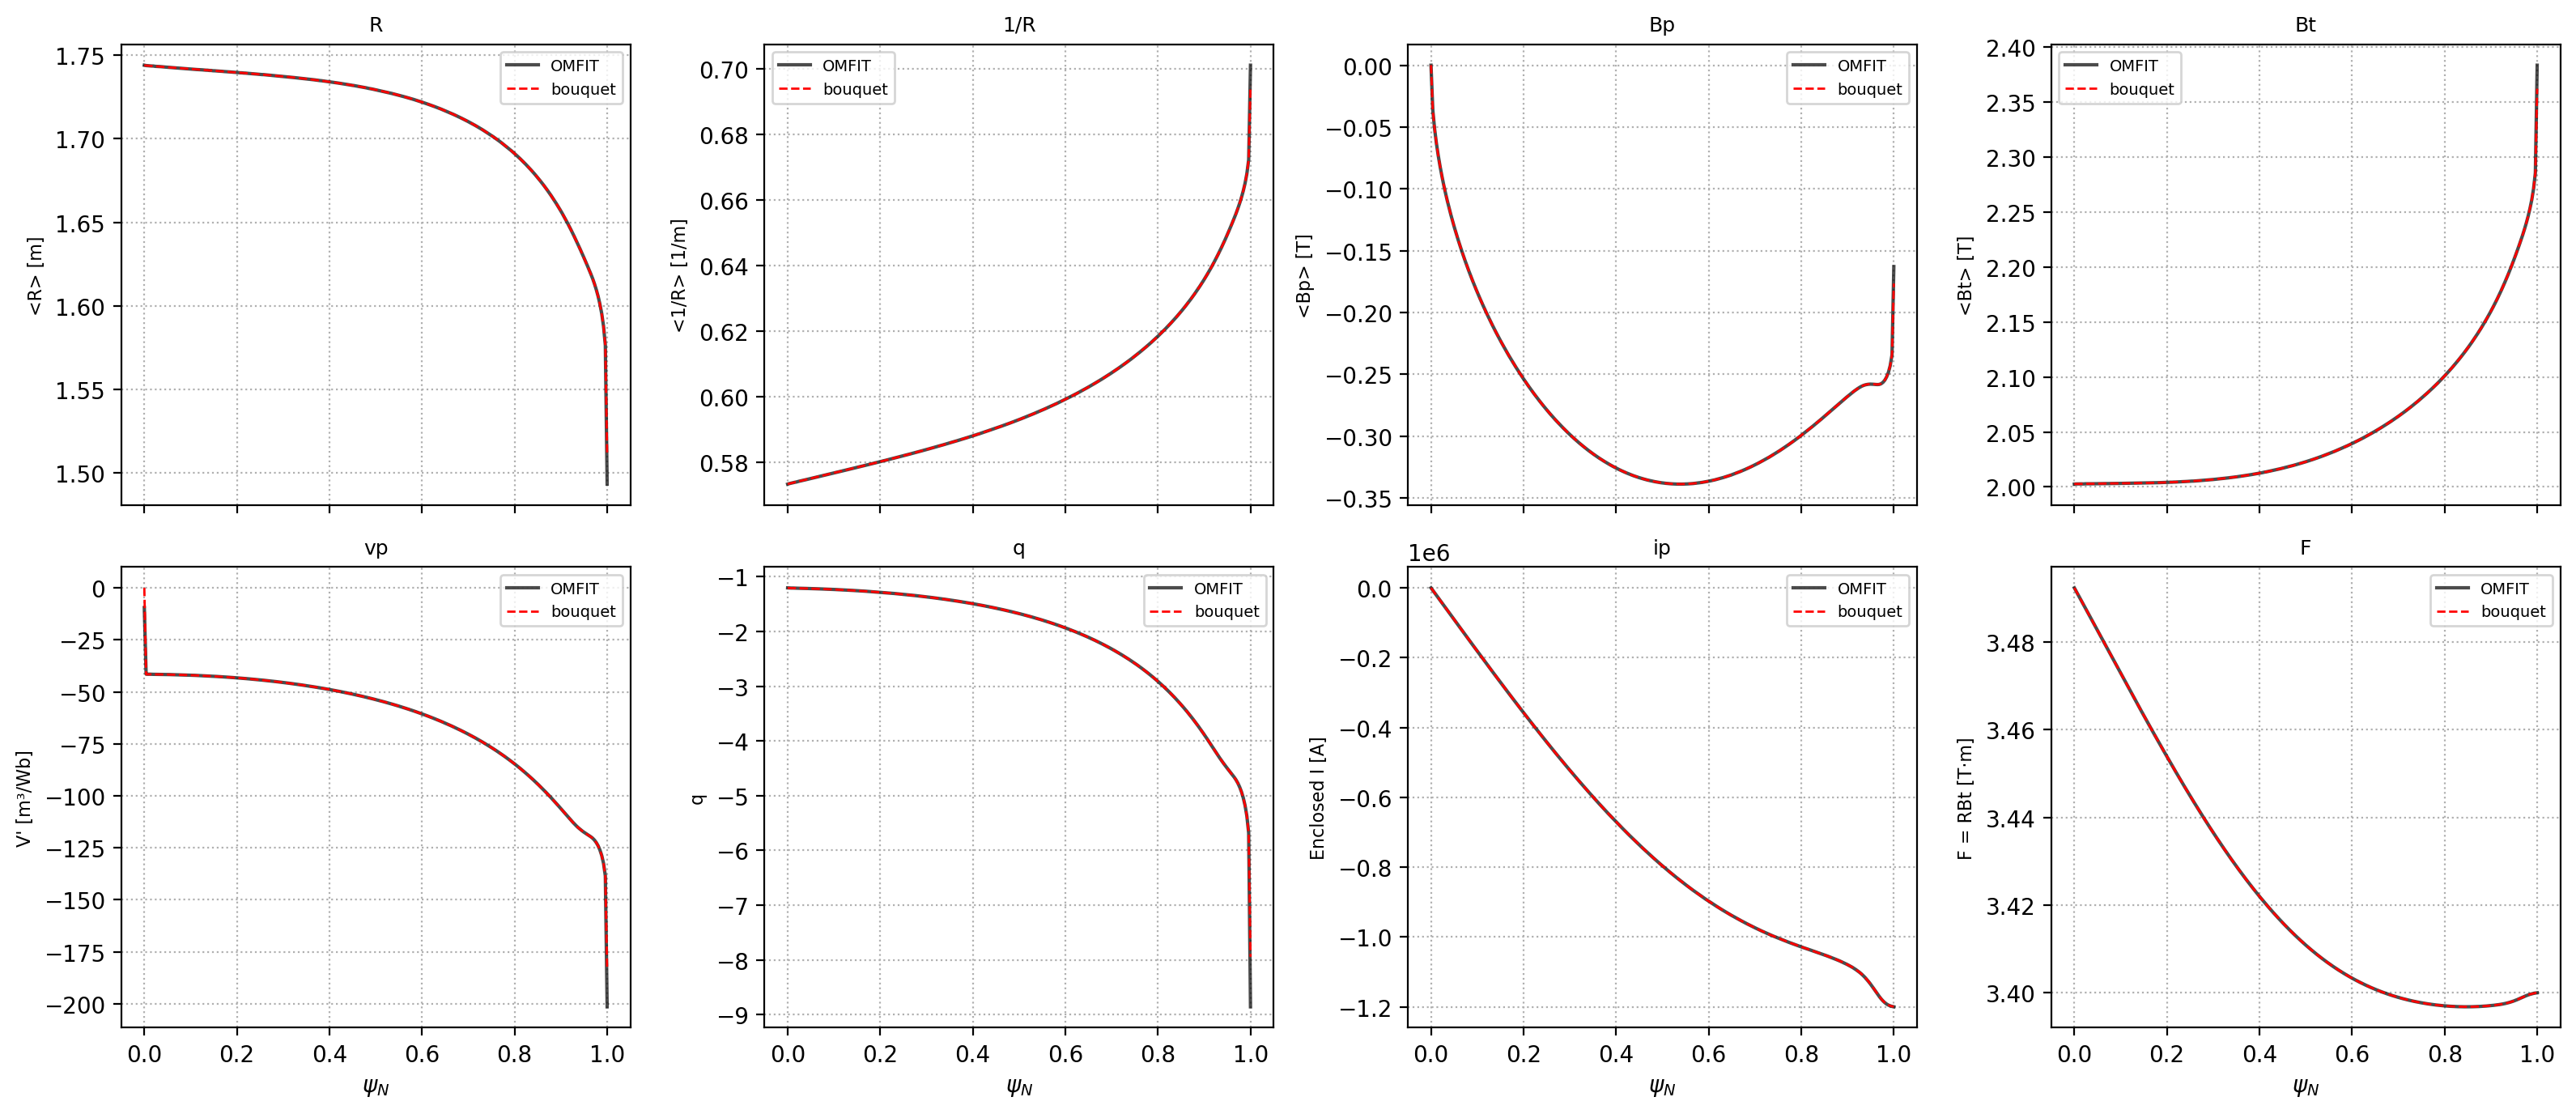

In [9]:
# Plot the most important averages
plot_keys = [
    ('R',     'averages/R',          eq.averages['R'],         '<R> [m]'),
    ('1/R',   'averages/1_over_R',   eq.averages['1/R'],       '<1/R> [1/m]'),
    ('Bp',    'averages/Bp',         eq.averages['Bp'],        '<Bp> [T]'),
    ('Bt',    'averages/Bt',         eq.averages['Bt'],        '<Bt> [T]'),
    ('vp',    'averages/vp',         eq.averages['vp'],        "V' [m³/Wb]"),
    ('q',     'averages/q',          eq.averages['q'],         'q'),
    ('ip',    'averages/ip',         eq.averages['ip'],        'Enclosed I [A]'),
    ('F',     'averages/F',          eq.averages['F'],         'F = RBt [T·m]'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for idx, (name, h5p, barr, ylabel) in enumerate(plot_keys):
    r, c = divmod(idx, 4)
    oarr = np.array(ref[h5p])
    plot_comparison(axes[r][c], eq.psi_N, barr, psi_N, oarr, ylabel, name)
axes[1][0].set_xlabel(r'$\psi_N$')
axes[1][1].set_xlabel(r'$\psi_N$')
axes[1][2].set_xlabel(r'$\psi_N$')
axes[1][3].set_xlabel(r'$\psi_N$')
plt.tight_layout()
plt.show()

## 9. Toroidal current density — three-way comparison

Bouquet computes $J_\phi$ in three ways:
1. **Standard** (`j_tor_averaged`): $\langle J_t/R \rangle / \langle 1/R \rangle$ — matches the OMFIT convention
2. **Direct GS** (`j_tor_averaged_direct`): $p'\langle R \rangle + FF'\langle 1/R \rangle / \mu_0$
3. **Numerical** (`j_tor_averaged_numerical`): from $\nabla \times \mathbf{B} / \mu_0$ sampled on contours

OMFIT stores a single `Jt` which is the numerical curl method.

TOROIDAL CURRENT DENSITY COMPARISON

bouquet standard vs OMFIT Jt (numerical):
  ✗ j_tor_std vs OMFIT         max=100.0000%  mean=  2.5209%  (N=257/257)

bouquet direct GS vs OMFIT Jt:
  ✗ j_tor_direct vs OMFIT      max=100.0000%  mean=  1.0602%  (N=257/257)

bouquet numerical vs OMFIT Jt:
  ✗ j_tor_num vs OMFIT         max=  8.4597%  mean=  0.0438%  (N=257/257)

bouquet standard vs bouquet direct (Jensen inequality):
  ✗ std vs direct              max= 20.4351%  mean=  2.0291%  (N=256/257)


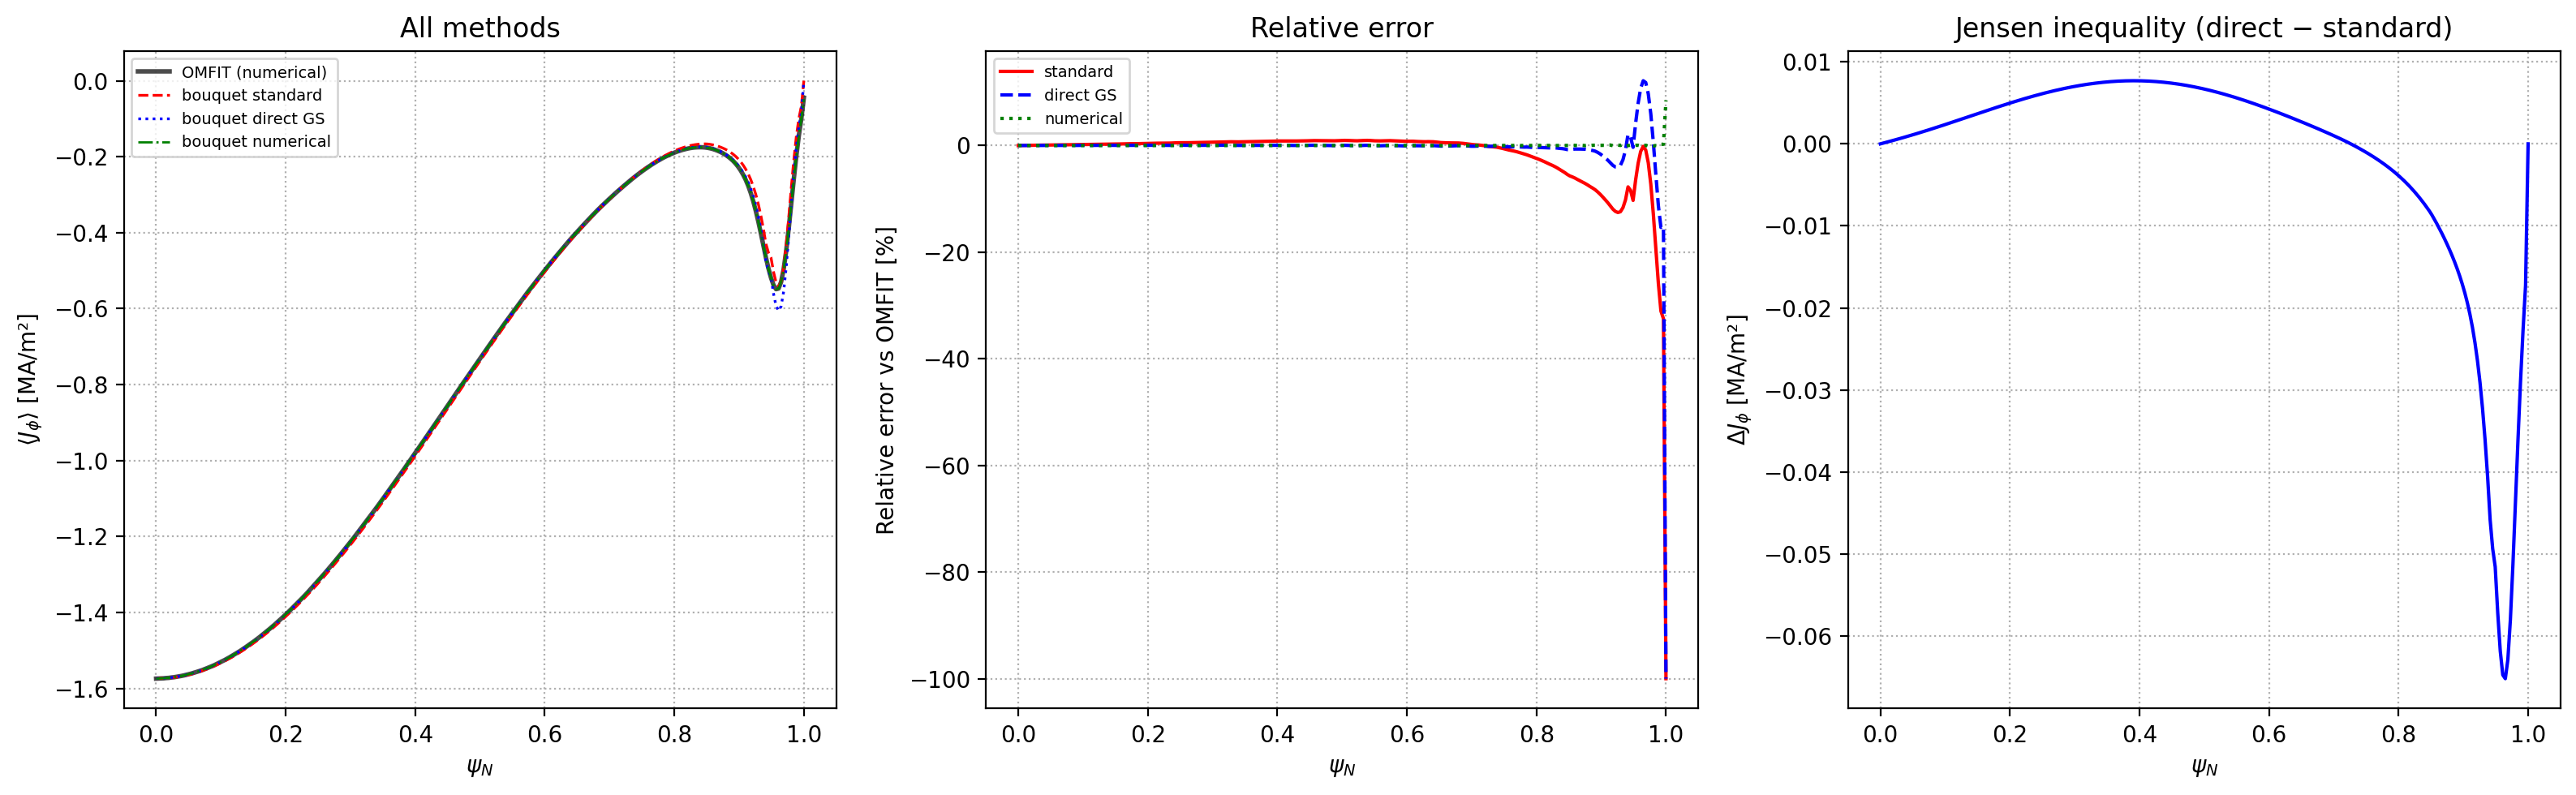

In [10]:
print("="*80)
print("TOROIDAL CURRENT DENSITY COMPARISON")
print("="*80)

jt_omfit = np.array(ref['averages/Jt'])
jt_bouquet_std = eq.j_tor_averaged
jt_bouquet_dir = eq.j_tor_averaged_direct
jt_bouquet_num = eq.j_tor_averaged_numerical

print("\nbouquet standard vs OMFIT Jt (numerical):")
compare_profile("j_tor_std vs OMFIT", jt_bouquet_std, jt_omfit)

print("\nbouquet direct GS vs OMFIT Jt:")
compare_profile("j_tor_direct vs OMFIT", jt_bouquet_dir, jt_omfit)

print("\nbouquet numerical vs OMFIT Jt:")
compare_profile("j_tor_num vs OMFIT", jt_bouquet_num, jt_omfit)

print("\nbouquet standard vs bouquet direct (Jensen inequality):")
compare_profile("std vs direct", jt_bouquet_std, jt_bouquet_dir,
                psi_b=eq.psi_N, psi_o=eq.psi_N)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: All four curves
ax = axes[0]
ax.plot(psi_N, jt_omfit/1e6, 'k-', lw=2, label='OMFIT (numerical)', alpha=0.7)
ax.plot(eq.psi_N, jt_bouquet_std/1e6, 'r--', lw=1.2, label='bouquet standard')
ax.plot(eq.psi_N, jt_bouquet_dir/1e6, 'b:', lw=1.2, label='bouquet direct GS')
ax.plot(eq.psi_N, jt_bouquet_num/1e6, 'g-.', lw=1.0, label='bouquet numerical')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel(r'$\langle J_\phi \rangle$ [MA/m²]')
ax.set_title('All methods')
ax.legend(fontsize=7)
ax.grid(ls=':')

# Panel 2: Relative error (standard vs OMFIT)
ax = axes[1]
mask = np.abs(jt_omfit) > 1e-10 * np.max(np.abs(jt_omfit))
rel_std = np.zeros_like(jt_omfit)
rel_std[mask] = (jt_bouquet_std[mask] - jt_omfit[mask]) / jt_omfit[mask] * 100
rel_dir = np.zeros_like(jt_omfit)
rel_dir[mask] = (jt_bouquet_dir[mask] - jt_omfit[mask]) / jt_omfit[mask] * 100
rel_num = np.zeros_like(jt_omfit)
rel_num[mask] = (jt_bouquet_num[mask] - jt_omfit[mask]) / jt_omfit[mask] * 100
ax.plot(eq.psi_N, rel_std, 'r-', label='standard')
ax.plot(eq.psi_N, rel_dir, 'b--', label='direct GS')
ax.plot(eq.psi_N, rel_num, 'g:', label='numerical')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('Relative error vs OMFIT [%]')
ax.set_title('Relative error')
ax.legend(fontsize=7)
ax.grid(ls=':')

# Panel 3: Jensen inequality
ax = axes[2]
jensen = jt_bouquet_dir - jt_bouquet_std
ax.plot(eq.psi_N, jensen/1e6, 'b-')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel(r'$\Delta J_\phi$ [MA/m²]')
ax.set_title('Jensen inequality (direct − standard)')
ax.grid(ls=':')

plt.tight_layout()
plt.show()

## 10. Geometric quantities

GEOMETRY COMPARISON
  ✗ vol                        max= 18.4801%  mean=  0.2809%  (N=256/257)
  ✗ cxArea                     max= 18.4758%  mean=  0.2794%  (N=256/257)
  ~ kappa                      max=  0.4751%  mean=  0.0078%  (N=257/257)
  ✗ delta                      max= 77.2829%  mean=  0.5970%  (N=256/257)
  ✓ Rmaj                       max=  0.0069%  mean=  0.0003%  (N=257/257)
  ✗ Zmag                       max=  6.0424%  mean=  0.1164%  (N=257/257)


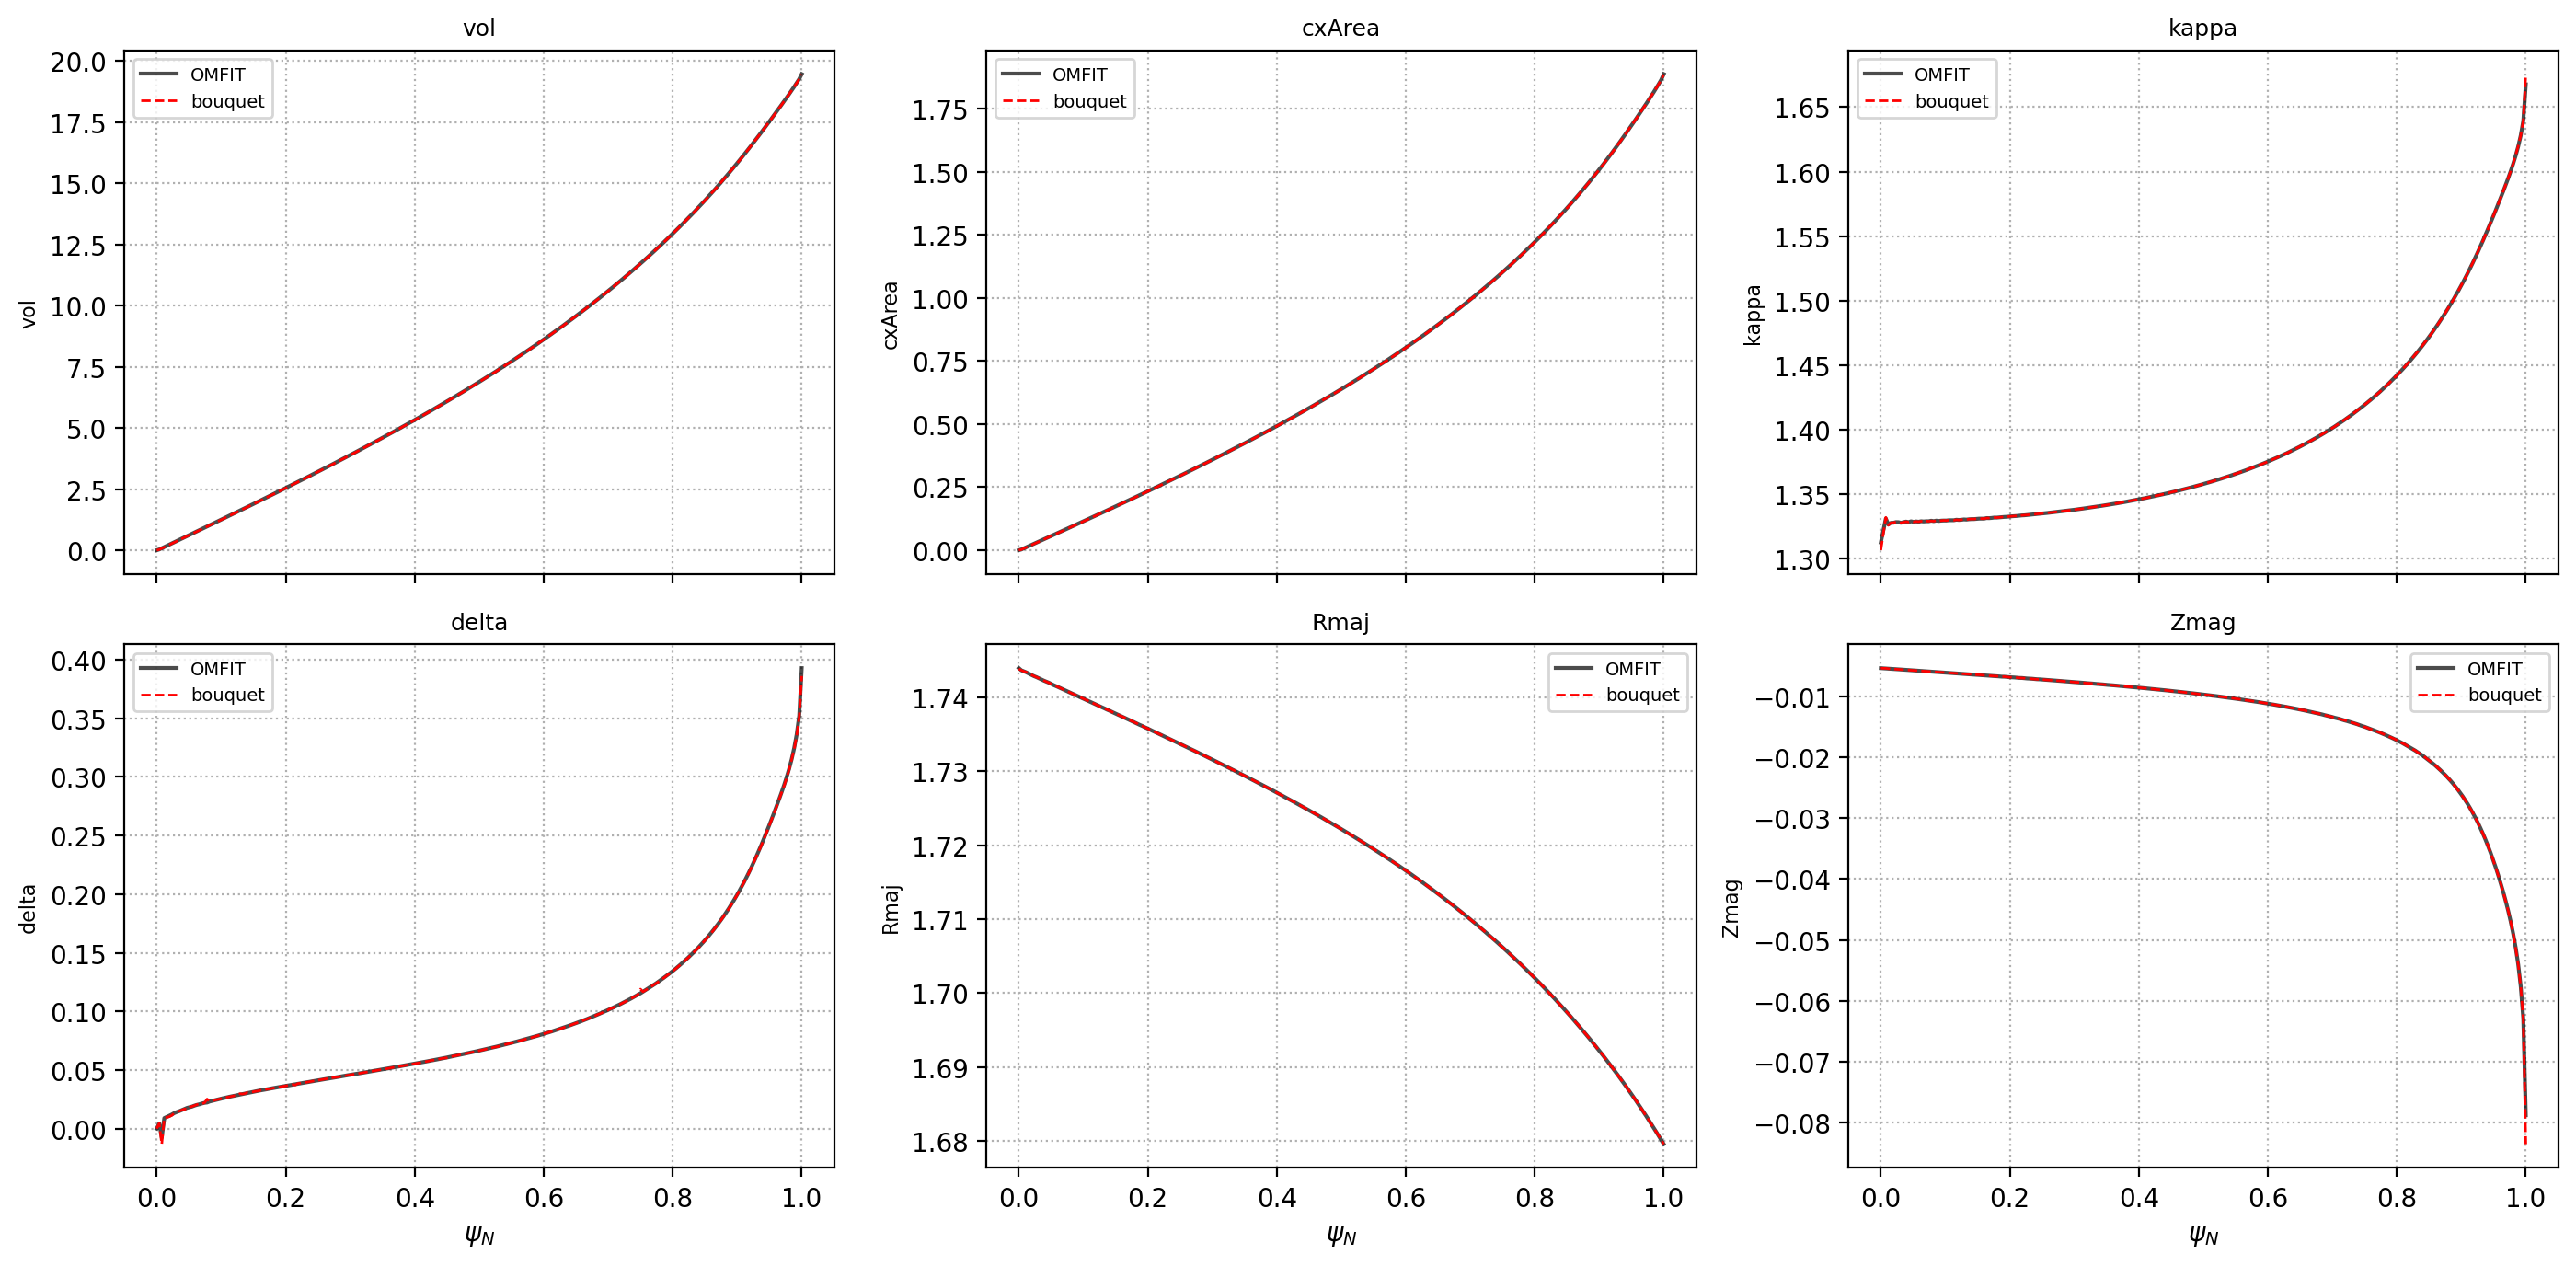

In [11]:
print("="*80)
print("GEOMETRY COMPARISON")
print("="*80)

geo = eq.geometry
geo_map = [
    ('vol',     'geometry/vol',      geo['vol']),
    ('cxArea',  'geometry/cxArea',   geo['cxArea']),
    ('kappa',   'geometry/kap',      geo['kappa']),
    ('delta',   'geometry/delta',    geo['delta']),
    ('Rmaj',    'geometry/R',        geo['R']),
    ('Zmag',    'geometry/Z',        geo['Z']),
]

for name, h5p, barr in geo_map:
    oarr = np.array(ref[h5p])
    compare_profile(name, barr, oarr)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for idx, (name, h5p, barr) in enumerate(geo_map):
    r, c = divmod(idx, 3)
    oarr = np.array(ref[h5p])
    plot_comparison(axes[r][c], eq.psi_N, barr, psi_N, oarr, name, name)
    if r == 1: axes[r][c].set_xlabel(r'$\psi_N$')
plt.tight_layout()
plt.show()

## 11. Internal inductance

In [12]:
print("="*80)
print("INTERNAL INDUCTANCE COMPARISON")
print("="*80)

li_bouquet = eq.li
li_omfit = dict(ref['info'].attrs)

print(f"  bouquet li(1) [std]:  {li_bouquet['li(1)']:.8f}")
print(f"  bouquet li(3) [iter]: {li_bouquet['li(3)']:.8f}")
print()
for k, v in li_omfit.items():
    if 'li' in k.lower() or 'inductance' in k.lower():
        print(f"  OMFIT {k}: {v:.8f}")

# Direct comparison
compare_scalar("li(1) vs OMFIT li_(1)_EFIT",
               li_bouquet['li(1)'], li_omfit.get('li_(1)_EFIT', 0))
compare_scalar("li(3) vs OMFIT li_(3)_IMAS",
               li_bouquet['li(3)'], li_omfit.get('li_(3)_IMAS', 0))

INTERNAL INDUCTANCE COMPARISON
  bouquet li(1) [std]:  1.06595706
  bouquet li(3) [iter]: 0.89768733

  OMFIT li_(1)_EFIT: 1.06171827
  OMFIT li_(1)_TLUCE: 1.12020403
  OMFIT li_(2)_TLUCE: 0.86524588
  OMFIT li_(3)_IMAS: 0.89841432
  OMFIT li_(3)_TLUCE: 0.89841432
  OMFIT li_from_definition: 1.06171827
  ~ li(1) vs OMFIT li_(1)_EFIT  bouquet=     1.0659571  omfit=     1.0617183  Δ=+4.239e-03  (0.3992%)
  ~ li(3) vs OMFIT li_(3)_IMAS  bouquet=    0.89768733  omfit=    0.89841432  Δ=-7.270e-04  (0.0809%)


0.08091851860784054

## 12. Outboard midplane field profiles

Bouquet computes exact outboard midplane quantities following OMFIT's
convention (`fluxSurface.py`):
- $R_{\rm mid} = R_{\rm geo} + a$ (outboard midplane intersection)
- $Z_{\rm mid} = Z_{\rm axis}$
- $B_r$, $B_z$ interpolated from the 2-D $\psi(R, Z)$ grid at $(R_{\rm mid}, Z_{\rm mid})$
- $B_p = \pm\sqrt{B_r^2 + B_z^2}$ with COCOS sign convention
- $B_t = F(\psi) / R_{\rm mid}$

In [ ]:
print("="*80)
print("OUTBOARD MIDPLANE COMPARISON")
print("="*80)

mid = eq.midplane

mid_map = [
    ('R',  'midplane/R',  mid['R'],  'R [m]'),
    ('Br', 'midplane/Br', mid['Br'], 'Br [T]'),
    ('Bz', 'midplane/Bz', mid['Bz'], 'Bz [T]'),
    ('Bp', 'midplane/Bp', mid['Bp'], 'Bp [T]'),
    ('Bt', 'midplane/Bt', mid['Bt'], 'Bt [T]'),
]

print("\nFull profile (including axis):")
for name, h5p, barr, _ in mid_map:
    oarr = np.array(ref[h5p])
    compare_profile(f"midplane {name}", barr, oarr)

# Exclude the axis (k=0) where Bp/Br/Bz ≈ 0 by definition
print("\nExcluding magnetic axis (ψ_N > 0):")
for name, h5p, barr, _ in mid_map:
    oarr = np.array(ref[h5p])
    compare_profile(f"midplane {name}", barr[1:], oarr[1:],
                    psi_b=eq.psi_N[1:], psi_o=psi_N[1:])

# --- Plots: bouquet vs OMFIT ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (name, h5p, barr, ylabel) in enumerate(mid_map):
    r, c = divmod(idx, 3)
    oarr = np.array(ref[h5p])
    plot_comparison(axes[r][c], eq.psi_N, barr, psi_N, oarr, ylabel,
                    f'Midplane {name}')
    axes[r][c].set_xlabel(r'$\psi_N$')

# Panel 6: Relative error for R, Bp, Bt (excluding axis)
ax = axes[1][2]
for name, h5p, barr, _ in [mid_map[0], mid_map[3], mid_map[4]]:
    oarr = np.array(ref[h5p])
    b1, o1 = barr[1:], oarr[1:]
    nz = np.abs(o1) > 1e-10 * np.max(np.abs(oarr))
    rel = np.zeros_like(o1)
    rel[nz] = (b1[nz] - o1[nz]) / o1[nz] * 100
    ax.plot(eq.psi_N[1:], rel, label=name)
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('Relative error [%]')
ax.set_title('Midplane relative error (excl. axis)')
ax.legend(fontsize=7)
ax.grid(ls=':')
ax.axhline(0, color='k', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

## 13. Summary table

In [ ]:
print("="*80)
print("COMPREHENSIVE ACCURACY SUMMARY")
print("="*80)

# Define radial regions
core    = (eq.psi_N > 0.0) & (eq.psi_N <= 0.5)
pedestal = (eq.psi_N > 0.5) & (eq.psi_N <= 0.95)
edge    = (eq.psi_N > 0.95) & (eq.psi_N < 1.0)
sep     = eq.psi_N == 1.0

def region_report(name, barr, oarr, mask):
    """Report max and mean relative error in a region."""
    b, o = barr[mask], oarr[mask]
    nz = np.abs(o) > 1e-10 * np.max(np.abs(oarr))
    if nz.sum() == 0:
        return None, None
    rel = np.abs((b[nz] - o[nz]) / o[nz]) * 100
    return rel.max(), rel.mean()

# Quantities to compare
categories = {
    'Raw FPOL':     (eq.fpol,   np.array(ref['profiles/FPOL'])),
    'Raw PRES':     (eq.pres,   np.array(ref['profiles/PRES'])),
    'Raw QPSI':     (eq.qpsi,   np.array(ref['profiles/QPSI'])),
    'Raw rhovn':    (eq.rhovn,  np.array(ref['profiles/rhovn'])),
    '<R>':          (eq.averages['R'],    np.array(ref['averages/R'])),
    '<1/R>':        (eq.averages['1/R'],  np.array(ref['averages/1_over_R'])),
    '<Bp>':         (eq.averages['Bp'],   np.array(ref['averages/Bp'])),
    '<Bt>':         (eq.averages['Bt'],   np.array(ref['averages/Bt'])),
    'q (averaged)': (eq.averages['q'],    np.array(ref['averages/q'])),
    "V'":           (eq.averages['vp'],   np.array(ref['averages/vp'])),
    'ip (enclosed)':(eq.averages['ip'],   np.array(ref['averages/ip'])),
    'Jt (numerical)': (eq.j_tor_averaged_numerical, np.array(ref['averages/Jt'])),
    'Volume':       (eq.geometry['vol'],  np.array(ref['geometry/vol'])),
    'kappa':        (eq.geometry['kappa'],np.array(ref['geometry/kap'])),
    'delta':        (eq.geometry['delta'],np.array(ref['geometry/delta'])),
    'Midplane R':   (eq.midplane['R'],    np.array(ref['midplane/R'])),
    'Midplane Bp':  (eq.midplane['Bp'],   np.array(ref['midplane/Bp'])),
    'Midplane Bt':  (eq.midplane['Bt'],   np.array(ref['midplane/Bt'])),
}

print(f"\n{'Category':<22s} | {'Core':>8s} | {'Pedestal':>8s} | {'Edge':>8s} | {'Sep':>8s}")
print(f"{'':<22s} | {'(max %)':>8s} | {'(max %)':>8s} | {'(max %)':>8s} | {'(max %)':>8s}")
print("-"*70)

for cat, (barr, oarr) in categories.items():
    vals = []
    for mask in [core, pedestal, edge, sep]:
        mx, mn = region_report(cat, barr, oarr, mask)
        vals.append(f"{mx:8.3f}" if mx is not None else "    N/A ")
    print(f"{cat:<22s} | {vals[0]} | {vals[1]} | {vals[2]} | {vals[3]}")

# Beta
print(f"\n{'--- Global scalars ---':^70s}")
for bk in ['beta_t', 'beta_p', 'beta_n']:
    b = eq.betas[bk]
    o = np.array(ref[f'averages/{bk}'])[-1]
    rel = abs(b - o) / abs(o) * 100
    print(f"  {bk:10s}: bouquet={b:.6f}  OMFIT={o:.6f}  err={rel:.3f}%")

li = eq.li
omfit_li = dict(ref['info'].attrs)
for lk, ok in [("li(1)", "li_(1)_EFIT"), ("li(3)", "li_(3)_IMAS")]:
    b, o = li[lk], omfit_li.get(ok, 0)
    rel = abs(b - o) / abs(o) * 100 if o != 0 else 0
    print(f"  {lk:10s}: bouquet={b:.6f}  OMFIT={o:.6f}  err={rel:.3f}%")

## 14. Cleanup

In [15]:
ref.close()
print('Done!')

Done!
